# Signal Blending

| Function | Description |
| --- | --- |
| `mix` | Weighted sum of signals. |
| `crossfade` | Linear crossfade between two signals. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine, generate_square
from python.mixing import crossfade, mix

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

`mix` and `crossfade` operations on a 440 Hz sine and square wave (3 cycles each).

**2 × 3 grid:**
- **Top-left — source signals:** sine (blue) and square (orange) overlaid for reference; the different waveshapes are clearly distinct
- **Top-centre — mix() at equal weights (0.5 / 0.5):** average of both signals; intermediate waveshape with rounded square-wave edges
- **Top-right — mix() at 80 / 20 weighting:** sine-dominant blend; square contributes only minor distortion to the otherwise sinusoidal shape

- **Bottom-left — crossfade() at five positions (p = 0, 0.25, 0.5, 0.75, 1):** all five blends overlaid; waveform shifts continuously from pure sine (blue) to pure square (red) as position increases
- **Bottom-centre — RMS vs position:** the 6 dB power dip at p = 0.5 from partial cancellation when two coherent signals are blended at equal weight
- **Bottom-right:** unused

`mix` takes explicit per-signal gain coefficients and supports any number of inputs; `crossfade` provides a single linear blend parameter p ∈ [0, 1] between exactly two signals.

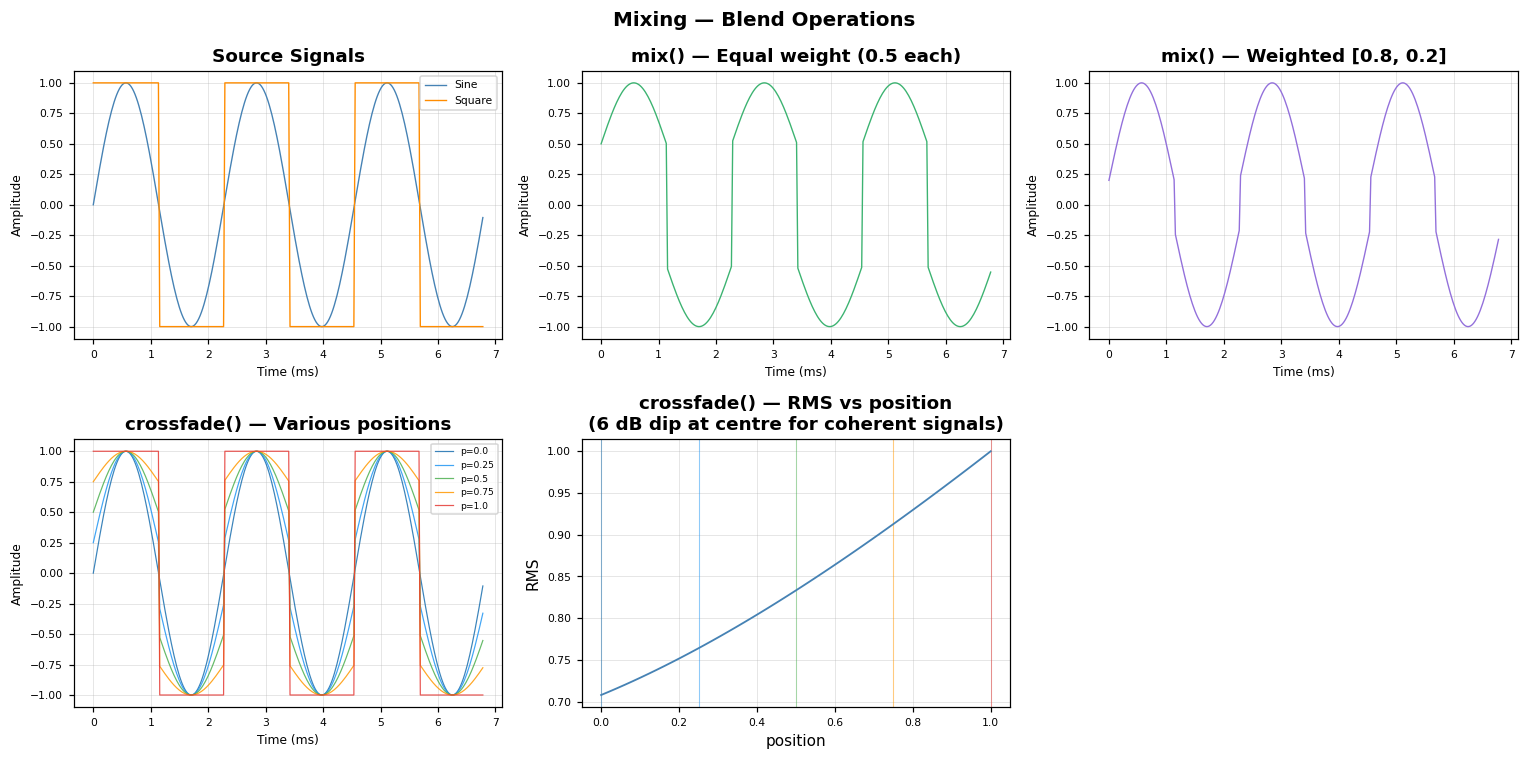

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 3 / FREQ

_, sine = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
_, square = generate_square(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sine)) / FS * 1000

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# mix: equal-weight average, then weighted
axes[0, 0].plot(t_ms, sine, linewidth=0.9, color="steelblue", label="Sine")
axes[0, 0].plot(t_ms, square, linewidth=0.9, color="darkorange", label="Square")
axes[0, 0].set_title("Source Signals", fontweight="bold")
axes[0, 0].legend(fontsize=7)

mixed_equal = mix([sine, square])
axes[0, 1].plot(t_ms, mixed_equal, linewidth=0.9, color="mediumseagreen")
axes[0, 1].set_title("mix() — Equal weight (0.5 each)", fontweight="bold")

mixed_weighted = mix([sine, square], weights=[0.8, 0.2])
axes[0, 2].plot(t_ms, mixed_weighted, linewidth=0.9, color="mediumpurple")
axes[0, 2].set_title("mix() — Weighted [0.8, 0.2]", fontweight="bold")

# crossfade at different positions
POSITIONS = [0.0, 0.25, 0.5, 0.75, 1.0]
COLORS = ["#1a6faf", "#2196f3", "#4caf50", "#ff9800", "#e53935"]
labels = [f"p={p}" for p in POSITIONS]

for pos, color, label in zip(POSITIONS, COLORS, labels):
    cf = crossfade(sine, square, position=pos)
    axes[1, 0].plot(t_ms, cf, linewidth=0.8, color=color, alpha=0.85, label=label)
axes[1, 0].set_title("crossfade() — Various positions", fontweight="bold")
axes[1, 0].legend(fontsize=6)

# crossfade power at center
for pos, color in zip(POSITIONS, COLORS):
    cf = crossfade(sine, square, position=pos)
    axes[1, 1].axvline(pos, color=color, linewidth=0.7, alpha=0.5)
rms_vals = [np.sqrt(np.mean(crossfade(sine, square, position=p) ** 2)) for p in np.linspace(0, 1, 50)]
p_range = np.linspace(0, 1, 50)
axes[1, 1].plot(p_range, rms_vals, color="steelblue", linewidth=1.2)
axes[1, 1].set_title("crossfade() — RMS vs position\n(6 dB dip at centre for coherent signals)", fontweight="bold")
axes[1, 1].set_xlabel("position")
axes[1, 1].set_ylabel("RMS")

axes[1, 2].set_visible(False)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.set_xlabel("Time (ms)", fontsize=8) if ax.get_visible() and ax != axes[1, 1] else None
    ax.set_ylabel("Amplitude", fontsize=8) if ax.get_visible() and ax != axes[1, 1] else None

fig.suptitle("Mixing — Blend Operations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

`mix` combines two signals with explicit per-signal weights — here a 440 Hz sine and a 660 Hz square give a two-pitch blend.

`crossfade` blends two signals via a single position parameter. The sweep clip below starts at pure 440 Hz sine (position = 0) and continuously morphs to pure 440 Hz square (position = 1) over 2 seconds, so the timbre shift is clearly audible.

In [3]:
from IPython.display import Audio, display

DUR_A = 2.0
N_A   = int(DUR_A * FS)
_, sine_a = generate_sine(freq=440.0, fs=FS, duration=DUR_A)
_, sq_a   = generate_square(freq=440.0, fs=FS, duration=DUR_A)
_, sq_b   = generate_square(freq=660.0, fs=FS, duration=DUR_A)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("mix([440 Hz sine, 660 Hz square]) — equal-weight sum, two pitches")
display(Audio(norm(mix([sine_a, sq_b])), rate=FS))

# crossfade sweep: position ramps 0→1 sample-by-sample over the full clip
positions = np.linspace(0.0, 1.0, N_A)
sweep = (1.0 - positions) * sine_a + positions * sq_a

print("crossfade sweep — pure 440 Hz sine (position=0) → pure 440 Hz square (position=1)")
display(Audio(norm(sweep), rate=FS))


mix([440 Hz sine, 660 Hz square]) — equal-weight sum, two pitches


crossfade sweep — pure 440 Hz sine (position=0) → pure 440 Hz square (position=1)
